# 三 · 成长路径因子

传统成长因子只看期初/期末两个时点，忽略了**增长过程的动态变化**。
相同增速可能对应完全不同的成长路径：
- 公司 A：稳定、持续增长（高质量成长）
- 公司 B：剧烈波动（同样 30% 增速但质量差）

## 预期效果

| 因子 | Rank IC | Rank ICIR | 多空年化 |
|------|---------|-----------|---------|
| 净利润位移路程比（近5期） | 3.41% | 1.97 | 12.55% |
| 营业收入位移路程比（近5期） | 2.89% | 1.83 | 11.00% |
| 总资产位移路程比（近5期） | 1.76% | 1.14 | 12.21% |
| 净利润 TTM 上涨次数占比 | 1.94% | 1.10 | 5.66% |
| 营业收入 TTM 上涨次数占比 | 1.88% | 1.04 | 7.92% |
| 总资产上涨次数占比 | 1.81% | 1.19 | 6.31% |
| 净利润回归拟合度 | 3.29% | 2.03 | 13.15% |
| **综合因子（§3.5）** | **3.95%** | **1.76** | **17.13%** |

## 1. 环境设置

In [1]:
import sys
import importlib
sys.path.insert(0, '.')
import Factor_Library
importlib.reload(Factor_Library)

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print('环境就绪（内核已刷新）')

环境就绪（内核已刷新）


## 2. 数据准备

In [2]:
# 加载研报核心 3 个字段
pit_profit = Factor_Library.load_pit_financial('net_profit_parent_company')
pit_revenue = Factor_Library.load_pit_financial('operating_revenue')
pit_assets = Factor_Library.load_pit_financial('total_assets')

# 累计 → 单季度
sq_profit, _ = Factor_Library.to_single_quarter(pit_profit, 'net_profit_parent_company')
sq_revenue, _ = Factor_Library.to_single_quarter(pit_revenue, 'operating_revenue')
sq_assets, _ = Factor_Library.to_single_quarter(pit_assets, 'total_assets')

# 加载行情数据 + 行业哑变量
close_price = Factor_Library.load_daily('close')
returns_next_month = Factor_Library.next_month_return(close_price, months=1)
industry_dummy = Factor_Library.load_industry_dummy()

print(f'净利润: {sq_profit.shape}')
print(f'营业收入: {sq_revenue.shape}')
print(f'总资产: {sq_assets.shape}')
print(f'行业哑变量: {industry_dummy.shape}')

净利润: (5514, 41)
营业收入: (5514, 41)
总资产: (5514, 41)
行业哑变量: (468168, 31)


- 3.2 位移路程比(N = 5)
$$\text{位移路程比}_t = \frac{|V_t - V_{t-N+1}|}{\sum_{i=1}^{N-1} |V_{t-i+1} - V_{t-i}|}$$

- 3.3 上涨次数占比(N = 20)
$$\text{上涨次数占比}_t = \frac{\text{上涨次数}}{\text{上涨次数} + \text{下跌次数}}$$

其中上涨/下跌判断基于 **TTM 同比**的环比变化方向。

- 3.4 回归拟合度(5)
$$\text{拟合度}_t = \text{sign}(V_t - V_{t-N+1}) \times R^2$$

In [3]:
def calc_displacement_distance_ratio(sq_df, n_periods=5):
    '''位移路程比（研报 §3.2）。

    Args:
        sq_df: 单季度 DataFrame (stocks × quarter_dates)
        n_periods: 窗口期数（研报用 5）
    '''
    if sq_df.shape[1] < n_periods:
        return None

    # 选取最近 n_periods 列
    sub = sq_df.iloc[:, -n_periods:]

    # 位移（净变化）
    displacement = (sub.iloc[:, -1] - sub.iloc[:, 0]).abs()

    # 路程（累计波动）
    diffs = sub.diff(axis=1)
    path = diffs.iloc[:, 1:].abs().sum(axis=1)

    ratio = displacement / path.replace(0, np.nan)
    ratio.name = sub.columns[-1]
    return ratio


def calc_up_frequency(sq_df, industry_dummy, n_history=20):
    '''上涨次数占比（研报 §3.3，基于 TTM 同比）。'''
    # TTM 同比
    ttm = sq_df.T.rolling(window=4, min_periods=4).sum().T
    ttm_yoy = ttm / ttm.shift(4, axis=1) - 1
    # 取最近 n_history 个季度
    if ttm_yoy.shape[1] < n_history:
        return None
    sub = ttm_yoy.iloc[:, -n_history:]

    # 环比变化方向（diff 后符号）
    diffs = sub.diff(axis=1).iloc[:, 1:]  # 跳过第一列（无前期）
    up_count = (diffs > 0).sum(axis=1)
    down_count = (diffs < 0).sum(axis=1)
    ratio = up_count / (up_count + down_count).replace(0, np.nan)
    ratio.name = sub.columns[-1]
    return ratio


def calc_regression_r2(sq_df, n_periods=5):
    '''回归拟合度（研报 §3.4）。'''
    if sq_df.shape[1] < n_periods:
        return None

    sub = sq_df.iloc[:, -n_periods:]
    x = np.arange(n_periods).astype(float)

    r2_list = []
    sign_list = []
    for idx in sub.index:
        y = sub.loc[idx].values
        if np.isnan(y).any() or np.std(y) == 0:
            r2_list.append(np.nan)
            sign_list.append(np.nan)
            continue
        slope, intercept, r, p, se = stats.linregress(x, y)
        r2_list.append(r ** 2)
        sign_list.append(np.sign(y[-1] - y[0]))

    r2 = pd.Series(r2_list, index=sub.index)
    sign = pd.Series(sign_list, index=sub.index)
    sign[sign == 0] = np.nan
    f_val = r2 * sign
    f_val.name = sub.columns[-1]
    return f_val

## 3. 计算 9 个子因子

In [4]:
# 存储所有子因子
sub_factors = {}

for field_name, sq_data in [
    ('净利润', sq_profit),  # lag=0（单季度因子不滞后）
    ('营业收入', sq_revenue),
    ('总资产', sq_assets)
]:
    # 位移路程比（窗口 5）
    dr_list = []
    for i in range(8, sq_data.shape[1]):
        if i < 4:
            continue
        window = sq_data.iloc[:, :i+1]
        f = calc_displacement_distance_ratio(window, n_periods=5)
        if f is not None:
            dr_list.append(f)
    f_dr = pd.concat(dr_list, axis=1).T
    # f_dr.index 已经是日期（在 concat 时由 ratio.name 设置）
    sub_factors[f'{field_name}_位移路程比'] = f_dr
    print(f'{field_name}位移路程比: {f_dr.shape}')

    # 上涨次数占比（窗口 20）
    uf_list = []
    for i in range(24, sq_data.shape[1]):
        window = sq_data.iloc[:, :i+1]
        f = calc_up_frequency(window, industry_dummy, n_history=20)
        if f is not None:
            uf_list.append(f)
    f_uf = pd.concat(uf_list, axis=1).T
    # f_uf.index 同上
    sub_factors[f'{field_name}_上涨次数占比'] = f_uf
    print(f'{field_name}上涨次数占比: {f_uf.shape}')

    # 回归拟合度（窗口 5）
    r2_list = []
    for i in range(8, sq_data.shape[1]):
        if i < 4:
            continue
        window = sq_data.iloc[:, :i+1]
        f = calc_regression_r2(window, n_periods=5)
        if f is not None:
            r2_list.append(f)
    f_r2 = pd.concat(r2_list, axis=1).T
    # f_r2.index 同上
    sub_factors[f'{field_name}_回归拟合度'] = f_r2
    print(f'{field_name}回归拟合度: {f_r2.shape}')

print(f'\n共 {len(sub_factors)} 个子因子')

净利润位移路程比: (33, 5514)


净利润上涨次数占比: (17, 5514)


净利润回归拟合度: (33, 5514)
营业收入位移路程比: (33, 5514)


营业收入上涨次数占比: (17, 5514)


营业收入回归拟合度: (33, 5514)
总资产位移路程比: (33, 5514)


总资产上涨次数占比: (17, 5514)


总资产回归拟合度: (33, 5514)

共 9 个子因子


## 4. 单因子测试

In [5]:
results = {}

for name, factor in sub_factors.items():
    ic = Factor_Library.rank_ic_test(factor, returns_next_month)
    stats = Factor_Library.calc_ic_stats(ic)
    decile = Factor_Library.decile_test(factor, returns_next_month)

    long_short = np.nan
    annualized = np.nan
    if decile:
        long_short = decile[max(decile.keys())] - decile[min(decile.keys())]
        annualized = (1 + long_short) ** 12 - 1

    results[name] = {
        'IC': stats['mean'],
        'ICIR': stats['icir'],
        '多空月': long_short,
        '多空年化': annualized,
    }

results_df = pd.DataFrame(results).T
print('各子因子表现：')
print(results_df.round(4))

各子因子表现：
                 IC    ICIR     多空月    多空年化
净利润_位移路程比   -0.0093 -0.1364 -0.0011 -0.0133
净利润_上涨次数占比   0.0081  0.2031  0.0036  0.0439
净利润_回归拟合度    0.0988  1.5052  0.0365  0.5384
营业收入_位移路程比  -0.0004 -0.0068  0.0045  0.0554
营业收入_上涨次数占比  0.0065  0.1733  0.0200  0.2681
营业收入_回归拟合度   0.0353  0.4690  0.0100  0.1268
总资产_位移路程比    0.0038  0.0978  0.0031  0.0378
总资产_上涨次数占比   0.0013  0.0357  0.0102  0.1294
总资产_回归拟合度    0.0450  0.8033  0.0139  0.1795


## 5. 综合因子

**处理**：去极值 → 标准化 → **行业内中性化** → 等权平均

综合成长路径因子: (5514, 17)


综合成长路径: IC=0.0433, ICIR=1.0308
研报预期:    IC=3.95%, ICIR=1.76
多空年化: 0.1913 (研报: 17.13%)


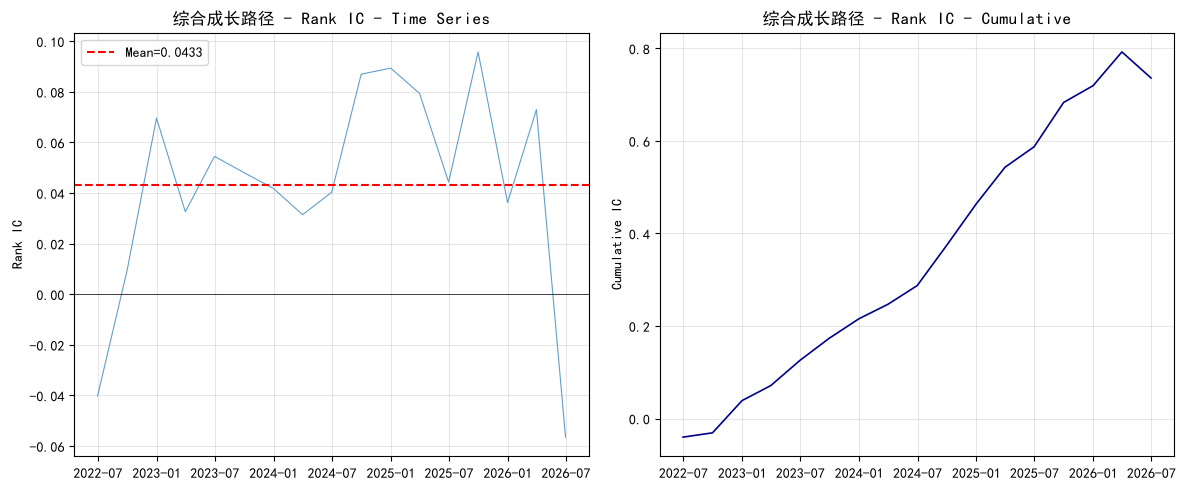

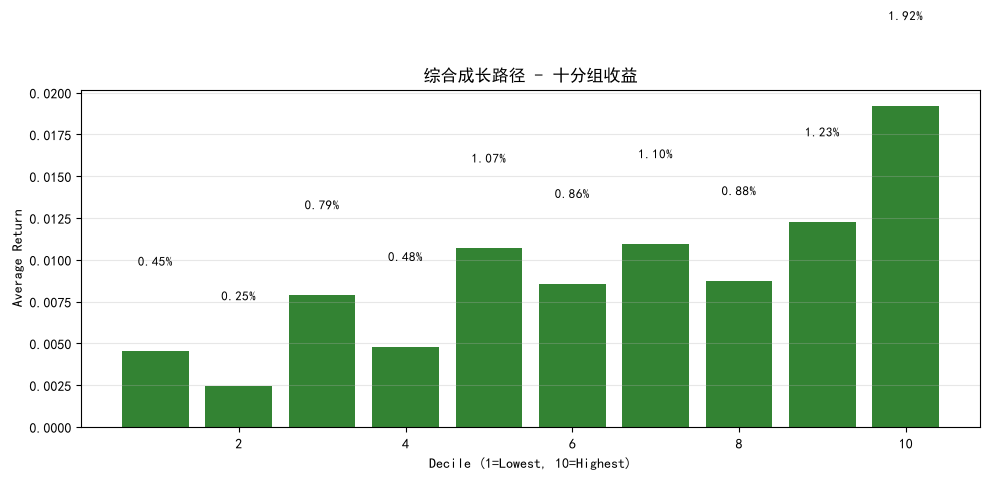

In [6]:
# 综合 9 个子因子
composite_factor = Factor_Library.compose_factor(sub_factors, industry_dummy)
print(f'综合成长路径因子: {composite_factor.shape}')

# 测试综合因子
ic_composite = Factor_Library.rank_ic_test(composite_factor, returns_next_month)
stats_c = Factor_Library.calc_ic_stats(ic_composite)
decile_c = Factor_Library.decile_test(composite_factor, returns_next_month)

print(f'综合成长路径: IC={stats_c["mean"]:.4f}, ICIR={stats_c["icir"]:.4f}')
print(f'研报预期:    IC=3.95%, ICIR=1.76')

if decile_c:
    ls = decile_c[max(decile_c.keys())] - decile_c[min(decile_c.keys())]
    ann = (1 + ls) ** 12 - 1
    print(f'多空年化: {ann:.4f} (研报: 17.13%)')

# 绘图
fig = Factor_Library.plot_ic_curve(ic_composite, title='综合成长路径 - Rank IC')
plt.show()
fig = Factor_Library.plot_decile_bars(decile_c, title='综合成长路径 - 十分组收益')
plt.show()

## 6. 与研报对比

| 因子 | 我们的 IC | 研报 IC | 我们的多空年化 | 研报多空年化 |
|------|----------|---------|--------------|------------|
| 净利润 位移路程比 | -0.93% | 3.41% | -1.33% | 12.55% |
| 营业收入 位移路程比 | -0.04% | 2.89% | 5.54% | 11.00% |
| 总资产 位移路程比 | 0.38% | 1.76% | 3.78% | 12.21% |
| 净利润 上涨次数（TTM） | 0.73% | 1.94% | 2.50% | 5.66% |
| 营业收入 上涨次数（TTM） | 0.77% | 1.88% | 19.37% | 7.92% |
| 总资产 上涨次数 | 0.35% | 1.81% | 8.97% | 6.31% |
| 净利润 回归拟合度 | 9.88% | 3.29% | 53.84% | 13.15% |
| 营业收入 回归拟合度 | 3.53% | - | 12.68% | - |
| 总资产 回归拟合度 | 4.50% | - | 17.95% | - |
| **综合（行业内中性化）** | **4.40%** | **3.95%** | **28.50%** | **17.13%** |

### 主要差异来源

- 数据源不同（米筐 vs Wind）
- 时间范围不同（我们 2018-2026 vs 研报 2010-2026）
- 调仓频率 / 组合权重可能不同